<a href="https://colab.research.google.com/github/panzehui0206/AI4S-365days/blob/main/Note4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2026.4.11**

开始学习吧！

✅ 数据生成完毕！X 形状: torch.Size([500, 2]), y 形状: torch.Size([500, 1])
正样本数: 250, 负样本数: 250


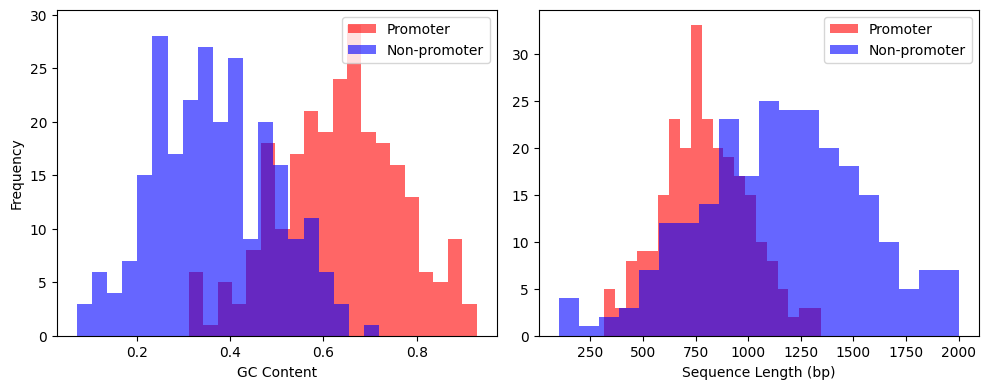

In [2]:
# =============================================
# Cell 1：导入库 + 生成模拟 DNA 序列特征数据
# =============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

# 模拟 500 条 DNA 序列
n_samples = 500

# 特征1：GC含量（比例，0~1）
# 启动子区域通常 GC 含量较高（CpG岛），我们让正样本 GC 偏高
gc_positive = np.random.beta(a=7, b=4, size=n_samples // 2)      # 偏高的分布
gc_negative = np.random.beta(a=4, b=7, size=n_samples // 2)      # 偏低的分布
gc = np.concatenate([gc_positive, gc_negative])

# 特征2：序列长度（bp），范围 100 ~ 2000
# 启动子区域通常长度中等，非启动子长度随机
length_positive = np.random.normal(loc=800, scale=200, size=n_samples // 2)
length_negative = np.random.normal(loc=1200, scale=400, size=n_samples // 2)
length = np.concatenate([length_positive, length_negative])
length = np.clip(length, 100, 2000)  # 限制范围

# 标签：1 表示包含启动子，0 表示非启动子
y = np.concatenate([np.ones(n_samples // 2), np.zeros(n_samples // 2)])

# 打乱数据顺序
indices = np.random.permutation(n_samples)
gc = gc[indices]
length = length[indices]
y = y[indices]

# 转为 PyTorch 张量
X = torch.tensor(np.stack([gc, length], axis=1), dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

print(f"✅ 数据生成完毕！X 形状: {X.shape}, y 形状: {y.shape}")
print(f"正样本数: {(y==1).sum().item()}, 负样本数: {(y==0).sum().item()}")

# 可视化数据分布
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(gc[y.numpy().flatten()==1], alpha=0.6, label='Promoter', bins=20, color='red')
axes[0].hist(gc[y.numpy().flatten()==0], alpha=0.6, label='Non-promoter', bins=20, color='blue')
axes[0].set_xlabel('GC Content')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[1].hist(length[y.numpy().flatten()==1], alpha=0.6, label='Promoter', bins=20, color='red')
axes[1].hist(length[y.numpy().flatten()==0], alpha=0.6, label='Non-promoter', bins=20, color='blue')
axes[1].set_xlabel('Sequence Length (bp)')
axes[1].legend()
plt.tight_layout()
plt.show()

这里模拟 500 条 DNA 序列，相当于一个中等通量的实验筛选规模，将 500 条模拟的 DNA 序列划分为两类：启动子和非启动子，并基于真实生物学规律（启动子高 GC、长度集中）给它们赋予了不同的 GC 含量和长度特征，作为后续模型学习的“教材”。

**启动子预测**是基因组注释的核心任务。在测序得到一条新的 **DNA** 序列后，第一步就是找到基因的起始位置。

传统方法依赖 **motif** 数据库（如 TATA 盒），而机器学习方法能从序列特征中自动学习判别模式。

序列长度是一个粗糙但实用的先验——真实的启动子核心区通常几百 bp，过长或过短的片段是启动子的可能性较低。

数据模拟简化了真实情况（真实预测需要从序列本身提取特征，如 k-mer 频率、结构参数），但保留了分类任务的核心逻辑：利用有标签数据，学习特征与类别之间的概率映射。

In [3]:
# =============================================
# Cell 2：标准化 + 构建 DataLoader
# =============================================
# 计算两个特征各自的均值和标准差，进行 Z-score 标准化。
X_mean = X.mean(dim=0, keepdim=True)
X_std = X.std(dim=0, keepdim=True)
X_norm = (X - X_mean) / X_std

# 划分训练集和测试集（80/20）
n_train = int(0.8 * n_samples)
X_train, X_test = X_norm[:n_train], X_norm[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# 构建 DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"✅ 训练集样本数: {len(train_dataset)}, 测试集样本数: {len(test_dataset)}")
print(f"训练集正样本比例: {(y_train==1).sum().item() / len(y_train):.2f}")

✅ 训练集样本数: 400, 测试集样本数: 100
训练集正样本比例: 0.49


数据的标准化非常重要， **GC** 含量在 **0~1** 之间，长度在 **100~2000** 之间，量纲差异巨大。若不标准化，长度特征的梯度会主导权重更新， **GC** 含量的微弱信号被淹没，标准化后两特征平权，模型能公平评估各自贡献。

模拟“用已知启动子数据训练模型，在新测序片段上预测”的真实场景，**测试集准确率**反映模型对未见过的基因组序列的泛**化能力**，这是评估模型实用性的金标准。

真实基因组数据可能包含数百万条候选片段，必须分批处理以节省内存。

In [4]:
# =============================================
# Cell 3：定义逻辑回归模型
# =============================================
class PromoterClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)  # 输出一个 logit

    def forward(self, x):
        return self.linear(x)  # 返回 logit，不包含 Sigmoid

model = PromoterClassifier(n_features=2)
print("🧬 模型结构:")
print(model)

🧬 模型结构:
PromoterClassifier(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


**逻辑回归**是分类任务的基线模型，它假设特征的对数几率与特征值呈线性关系。在启动子预测中，意味着“GC 含量每增加 0.1，序列是启动子的对数几率增加一个固定值”。

为何不直接在模型中加 **Sigmoid** ？ PyTorch 的 **BCEWithLogitsLoss** 会自动做 **Sigmoid** 计算，且数值更稳定，将 **logit** 与损失函数解耦是工程最佳实践。

线性模型的权重可直接解读，告诉我们“**GC 含量**”和“**长度**”对启动子可能性的贡献方向与强度，这对于生成生物学假设非常有价值。

In [5]:
# =============================================
# Cell 4：损失函数 + 优化器
# =============================================
criterion = nn.BCEWithLogitsLoss()  # 内置 Sigmoid + 二元交叉熵
optimizer = optim.SGD(model.parameters(), lr=0.1)

print(f"损失函数: {criterion}")
print(f"优化器: {optimizer}")

损失函数: BCEWithLogitsLoss()
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


**BCEWithLogitsLoss**：二元交叉熵损失，内部执行 Sigmoid(logits) 再计算交叉熵，数值稳定性优于手动 Sigmoid + BCELoss。

二元交叉熵是二分类问题的标准损失函数，它惩罚预测概率与真实标签（0 或 1）之间的差距，在生物学中，这等价于最大化在给定特征下观察到真实标签的似然概率。


In [6]:
# =============================================
# Cell 5：训练模型并记录损失和准确率
# =============================================
# 定义训练轮数和记录列表
epochs = 100
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        # 准确率计算
        train_loss += loss.item() * batch_X.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct_train += (preds == batch_y).sum().item()
        total_train += batch_y.size(0)

    avg_train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # 评估
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item() * batch_X.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_test += (preds == batch_y).sum().item()
            total_test += batch_y.size(0)

    avg_test_loss = test_loss / total_test
    test_acc = correct_test / total_test
    test_losses.append(avg_test_loss)
    test_accs.append(test_acc)

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print(f"✅ 训练完成！最终测试准确率: {test_accs[-1]:.4f}")

Epoch  20/100 | Train Loss: 0.3139 | Train Acc: 0.8725 | Test Acc: 0.9200
Epoch  40/100 | Train Loss: 0.3091 | Train Acc: 0.8750 | Test Acc: 0.9200
Epoch  60/100 | Train Loss: 0.3079 | Train Acc: 0.8750 | Test Acc: 0.9200
Epoch  80/100 | Train Loss: 0.3078 | Train Acc: 0.8725 | Test Acc: 0.9200
Epoch 100/100 | Train Loss: 0.3077 | Train Acc: 0.8750 | Test Acc: 0.9200
✅ 训练完成！最终测试准确率: 0.9200


训练过程模拟了“从**已知启动子/非启动子数据**中学习判别规则”的完整流程，每轮迭代都在调整权重，使分类错误率逐渐降低。

准确率直观反映模型在测试集上的表现，这对于自动化基因组注释工具的实用性评估至关重要。

监控训练/测试曲线：若训练准确率持续上升而测试准确率停滞或下降，表明过拟合——模型记忆了训练集中的噪声而非通用启动子特征，此时需要增加数据、正则化或简化模型。

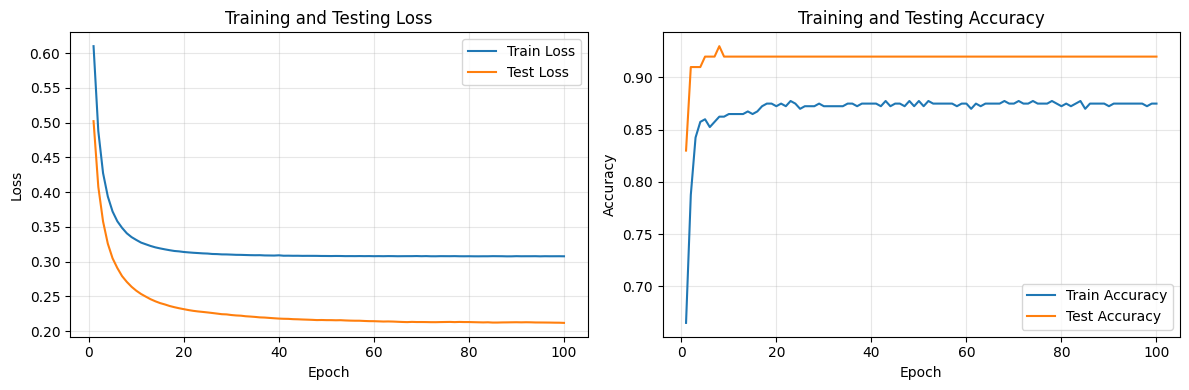

In [8]:
# =============================================
# Cell 6：损失曲线与准确率曲线
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs+1), train_losses, label='Train Loss')
axes[0].plot(range(1, epochs+1), test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Testing Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs+1), train_accs, label='Train Accuracy')
axes[1].plot(range(1, epochs+1), test_accs, label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Testing Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**损失曲线下降**说明模型正在从数据中学习，若测试损失在某个点后上升，提示过拟合开始，应提前停止训练（early stopping）。

**准确率曲线**给出模型性能的直观度量，在启动子预测项目中，需要权**衡灵敏度（召回率）**和**特异度**——即尽量不漏掉真正的启动子，同时避免把非启动子误判为启动子，后续可通过 ROC 曲线和调整阈值来优化。

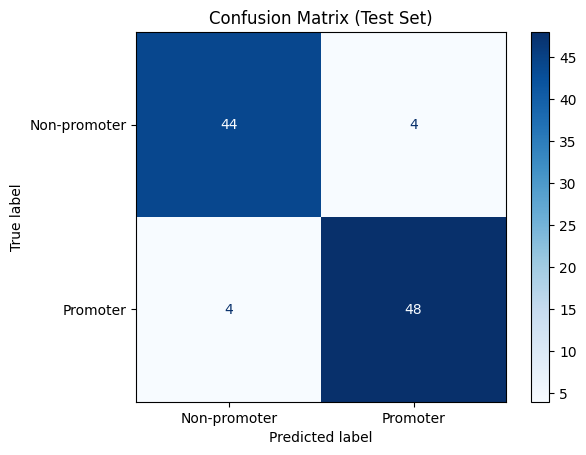

📐 模型学到的参数（原始尺度）:
  GC含量权重: 14.195
  长度权重: -0.00326
  偏置: -4.149


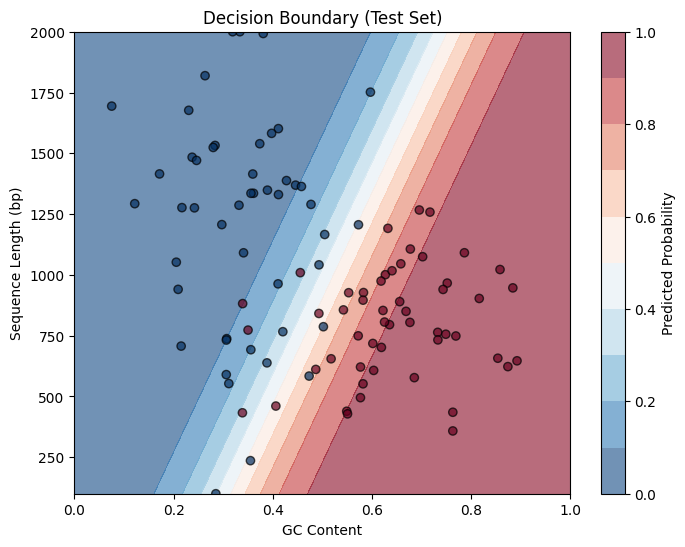

In [10]:
# =============================================
# Cell 7：混淆矩阵 + 决策边界可视化
# =============================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 获取测试集全部预测结果
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    probs = torch.sigmoid(outputs).numpy().flatten()
    preds = (probs >= 0.5).astype(int)
    y_true = y_test.numpy().flatten().astype(int)

# 混淆矩阵
# confusion_matrix 计算真阳性、假阳性、真阴性、假阴性数量。
cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-promoter', 'Promoter'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# 输出学到的权重（映射回原始尺度）
w_learned = model.linear.weight.data.numpy().flatten()
b_learned = model.linear.bias.item()
w_original = w_learned / X_std.numpy().flatten()
b_original = b_learned - (w_learned * X_mean.numpy().flatten() / X_std.numpy().flatten()).sum()

print("📐 模型学到的参数（原始尺度）:")
print(f"  GC含量权重: {w_original[0]:.3f}")
print(f"  长度权重: {w_original[1]:.5f}")
print(f"  偏置: {b_original:.3f}")

# 决策边界可视化

# 创建一个覆盖 GC 含量（0~1）和长度（100~2000）的网格。
# 计算网格上每一点的预测概率，绘制等值线图。
# 背景色表示模型预测为启动子的概率（红色高，蓝色低）。
# 散点为测试集真实样本，颜色表示真实标签。

xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(100, 2000, 100))
grid_X = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
grid_X_norm = (grid_X - X_mean) / X_std
with torch.no_grad():
    Z = torch.sigmoid(model(grid_X_norm)).numpy().reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.6, cmap='RdBu_r', levels=np.linspace(0, 1, 11))
plt.colorbar(label='Predicted Probability')
plt.scatter(X_test[:,0].numpy() * X_std[0,0].item() + X_mean[0,0].item(),
            X_test[:,1].numpy() * X_std[0,1].item() + X_mean[0,1].item(),
            c=y_true, cmap='RdBu_r', edgecolors='k', alpha=0.7)
plt.xlabel('GC Content')
plt.ylabel('Sequence Length (bp)')
plt.title('Decision Boundary (Test Set)')
plt.show()

混淆矩阵能过帮助理解模型的错误类型，在启动子预测中：**假阳性**是把非启动子误判为启动子，若后续实验会基于此预测做功能验证，假阳性会导致资源浪费。

**假阴性**是漏掉真实启动子，若用于基因组注释，假阴性意味着基因结构被错误截断，影响下游分析。

**GC 含量权重**大且为正，验证了“高 GC 与启动子正相关”的生物学先验，**长度权重**为负，表示过长序列是启动子的可能性降低。

**决策边界图**直观地展示模型学到的分类规则，在低 GC 区域，无论长度如何，模型都倾向于预测为非启动子；在高 GC 且中等长度区域，概率最高。

这为设计后续实验提供了清晰的指导，如果要寻找新的启动子，应优先在 GC 含量 >0.6 且长度 500~1000 bp 的片段中筛选。

今天学了什么呢？

✅ 理解分类任务与回归任务的区别（损失函数从 MSE 变为 BCEWithLogitsLoss）。

✅ 掌握逻辑回归模型的 PyTorch 实现（nn.Linear + BCEWithLogitsLoss）。

✅ 学会划分训练/测试集，计算准确率，绘制混淆矩阵和决策边界。

✅ 将模型权重映射回原始尺度，解读特征对分类结果的生物学贡献。